# Exoplanet Classification Machine Learning Model

### Model for classifying habitable planets based on available data from NASA exoplanet database.

In [58]:
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch

from scipy.stats import norm

import sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score

### Data Display

In [38]:
df_base = pd.read_csv('/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/data/consolidated_exoplanets.csv', low_memory=False)

display(df_base.shape)
display(df_base)
df_base.info()

(6153, 408)

,pl_name,pl_letter,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,pl_refname,...,simbad_sp_type,simbad_radvel,source_simbad,hz_inner_opt,hz_outer_opt,hz_inner_con,hz_outer_con,in_habitable_zone,source_hec,habitability_labeled
0,HD 114783 b,b,HD 114783,HD 114783,HIP 64457,TIC 292113181,Gaia DR2 3684934540986187776,Gaia DR3 3684934540986187776,1,<a refstr=WITTENMYER_ET_AL__2009 href=https://...,...,K1V,-11.966,True,1.240717,3.009643,1.639675,2.877374,False,True,True
1,HD 12661 c,c,HD 12661,HD 12661,HIP 9683,TIC 118268680,Gaia DR2 105332908999068032,Gaia DR3 105332908999068032,1,<a refstr=LIU_ET_AL__2014 href=https://ui.adsa...,...,NaN,NaN,False,0.807798,1.903851,1.057131,1.820601,False,True,True
2,HD 27894 c,c,HD 27894,HD 27894,HIP 20277,TIC 396697266,Gaia DR2 4678605152248591488,Gaia DR3 4678605152248591488,1,<a refstr=TRIFONOV_ET_AL__2017 href=https://ui...,...,NaN,NaN,False,1.197218,2.950316,1.587025,2.819080,False,True,True
3,TOI-4010 b,b,TOI-4010,NaN,NaN,TIC 352682207,Gaia DR2 525352325110310400,Gaia DR3 525352325110310400,1,<a refstr=KUNIMOTO_ET_AL__2023 href=https://ui...,...,NaN,4.580,False,1.213779,2.969751,1.607080,2.838520,False,True,True
4,HD 12661 b,b,HD 12661,HD 12661,HIP 9683,TIC 118268680,Gaia DR2 105332908999068032,Gaia DR3 105332908999068032,1,<a refstr=STASSUN_ET_AL__2017 href=https://ui....,...,NaN,NaN,False,3.408449,8.070694,4.469174,7.717782,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6148,HD 66428 c,c,HD 66428,HD 66428,HIP 39417,TIC 73238215,Gaia DR2 3083043390405346432,Gaia DR3 3083043390405346432,1,<a refstr=FENG_ET_AL__2022 href=https://ui.ads...,...,NaN,NaN,False,2.970323,7.034778,3.895036,6.727163,False,True,True
6149,HD 3167 c,c,HD 3167,HD 3167,HIP 2736,TIC 318707987,Gaia DR2 2554032474712538880,Gaia DR3 2554032474712538880,1,<a refstr=BONOMO_ET_AL__2023 href=https://ui.a...,...,NaN,NaN,False,NaN,NaN,NaN,NaN,False,True,True
6150,HD 62364 b,b,HD 62364,HD 62364,HIP 36941,TIC 271972463,Gaia DR2 5214209564293214208,Gaia DR3 5214209564293214208,1,<a refstr=FRENSCH_ET_AL__2023 href=https://ui....,...,NaN,NaN,False,1.212193,2.795949,1.569559,2.673926,False,True,True
6151,HD 221420 b,b,HD 221420,HD 221420,HIP 116250,TIC 277890728,Gaia DR2 6353376831270492800,Gaia DR3 6353376831270492800,1,<a refstr=VENNER_ET_AL__2021 href=https://ui.a...,...,G2IV-V,26.504,True,1.498078,3.515234,1.956638,3.361518,False,True,True


<class 'pandas.DataFrame'>
RangeIndex: 6153 entries, 0 to 6152
Columns: 408 entries, pl_name to habitability_labeled
dtypes: bool(5), float64(288), int64(25), str(90)
memory usage: 18.9 MB


### Data Cleaning

In [39]:
# Dropping columns

df = df_base.copy()

# ── Target ──
TARGET = "P_HABITABLE"

# ── Features ──
# Planetary physical/orbital properties
PLANET_FEATURES = [
    "pl_orbper",       # orbital period (days)
    "pl_orbsmax",      # semi-major axis (AU)
    "pl_orbeccen",     # eccentricity
    "pl_bmasse",       # planet mass (Earth masses)
    "pl_rade",         # planet radius (Earth radii)
    "pl_dens",         # planet density (g/cm^3)
    "pl_eqt",          # equilibrium temperature (K)
    "pl_insol",        # insolation flux (Earth flux)
]

# Stellar properties
STELLAR_FEATURES = [
    "st_teff",         # effective temperature (K)
    "st_rad",          # stellar radius (solar radii)
    "st_mass",         # stellar mass (solar masses)
    "st_lum",          # luminosity (log solar)
    "st_met",          # metallicity (dex)
    "st_logg",         # surface gravity (log cgs)
    "st_age",          # age (Gyr)
]

# Derived physical features (from your consolidation pipeline)
DERIVED_FEATURES = [
    "P_GRAVITY",       # surface gravity (Earth units)
    "P_DENSITY",       # density (Earth units)
    "P_ESCAPE",        # escape velocity (Earth units)
]

# System
SYSTEM_FEATURES = [
    "sy_dist",         # distance (pc)
]

BASEFEATURES = PLANET_FEATURES + STELLAR_FEATURES + DERIVED_FEATURES + SYSTEM_FEATURES

# NOTE: P_ESI and in_habitable_zone are excluded — they are direct habitability proxies and would cause data leakage.

# ── Keep only relevant columns ──
df = df[BASEFEATURES + [TARGET]].copy()

# ── Drop rows without a habitability label ──
df = df.dropna(subset=[TARGET])
display(df)

,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmasse,pl_rade,pl_dens,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_lum,st_met,st_logg,st_age,P_GRAVITY,P_DENSITY,P_ESCAPE,sy_dist,P_HABITABLE
0,493.700000,1.1600,0.144,349.600000,NaN,NaN,213.399153,NaN,5135.000,0.861593,0.853,0.414485,0.2100,4.4936,NaN,1.862646,0.135960,5.051559,21.0628,0.0
1,1708.000000,2.8145,0.031,575.884000,NaN,NaN,174.063547,NaN,5748.000,1.110000,1.020,0.063000,0.3600,4.3095,6.390000,3.207195,0.239343,6.555640,37.8478,0.0
2,36.070000,0.1980,0.015,51.488460,NaN,NaN,488.827166,NaN,4815.887,0.877330,0.800,0.373056,0.3000,4.5033,NaN,0.758325,0.092030,2.499720,43.8214,0.0
3,1.348335,0.0229,0.030,11.000000,3.02,2.20,1441.000000,714.000,4960.000,0.830000,0.880,0.389617,0.3700,4.5400,6.100000,1.206087,0.399367,1.908503,177.5040,0.0
4,262.708620,0.8400,0.380,772.326900,NaN,NaN,325.345747,NaN,5645.000,1.200000,1.200,1.309892,0.3600,4.3600,NaN,4.366142,0.328281,7.620347,37.8478,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6147,223.920000,0.7710,0.228,127.131363,NaN,NaN,393.448053,NaN,6123.000,1.369116,1.220,2.101674,0.3000,4.3900,2.500000,0.653145,0.048742,2.958402,51.2610,0.0
6148,10478.844370,9.4080,0.207,560.649310,NaN,NaN,94.788476,NaN,5640.325,1.142720,1.010,1.190222,0.3691,4.3298,12.130959,3.076265,0.227871,6.444345,53.2817,0.0
6149,29.845400,0.1776,0.060,11.130000,3.00,2.11,564.000000,16.900,5261.000,0.880000,0.837,NaN,0.0400,NaN,7.800000,1.236667,0.412222,1.926136,47.2899,0.0
6150,5138.000000,6.1500,0.607,5965.639199,NaN,NaN,143.959070,0.072,6255.000,1.401000,1.157,0.432970,-0.1100,4.1400,3.901000,40.746118,3.367448,22.204235,53.1120,0.0


### Data Cleaning - Samples

In [40]:
# ── Tier 1: Drop high-missingness features ──
# pl_dens (83% missing, redundant with P_DENSITY)
# pl_insol (88% missing, captured by pl_eqt + st_lum + pl_orbsmax)
FEATURES = [
    "pl_orbper", "pl_orbsmax", "pl_orbeccen", "pl_bmasse", "pl_rade",
    "pl_eqt",
    "st_teff", "st_rad", "st_mass", "st_lum", "st_met", "st_logg", "st_age",
    "P_GRAVITY", "P_DENSITY", "P_ESCAPE",
    "sy_dist",
]

df = df[FEATURES + [TARGET]].copy()
df = df.dropna(subset=[TARGET])
print(f"After target filter: {df.shape}")
print(f"Nulls before imputation:\n{df[FEATURES].isnull().sum()}\n")

# =====================================================================
# Tier 2: Physics-Based Imputation (order matters)
# =====================================================================

# 2a) Eccentricity → 0.0 (unmeasured ≈ circular orbit)
n_ecc = df["pl_orbeccen"].isna().sum()
df["pl_orbeccen"] = df["pl_orbeccen"].fillna(0.0)
print(f"[Tier 2a] pl_orbeccen: filled {n_ecc} with 0.0")

# 2b) Semi-major axis from Kepler's 3rd law: a = (P² × M★)^(1/3)
#     P in years, M★ in solar masses → a in AU
mask_a = df["pl_orbsmax"].isna() & df["pl_orbper"].notna() & df["st_mass"].notna()
P_yr = df.loc[mask_a, "pl_orbper"] / 365.25
df.loc[mask_a, "pl_orbsmax"] = (P_yr**2 * df.loc[mask_a, "st_mass"])**(1/3)
print(f"[Tier 2b] pl_orbsmax: filled {mask_a.sum()} via Kepler's 3rd law")

# 2c) Orbital period from Kepler's 3rd law inverse: P = sqrt(a³ / M★) in years → days
mask_p = df["pl_orbper"].isna() & df["pl_orbsmax"].notna() & df["st_mass"].notna()
a = df.loc[mask_p, "pl_orbsmax"]
P_yr_inv = np.sqrt(a**3 / df.loc[mask_p, "st_mass"])
df.loc[mask_p, "pl_orbper"] = P_yr_inv * 365.25
print(f"[Tier 2c] pl_orbper: filled {mask_p.sum()} via Kepler's 3rd law (inverse)")

# 2d) Luminosity from Stefan-Boltzmann: L/L_sun = (R/R_sun)² × (T/T_sun)⁴
#     st_lum is stored as log10(L/L_sun)
mask_lum = df["st_lum"].isna() & df["st_teff"].notna() & df["st_rad"].notna()
L_linear = df.loc[mask_lum, "st_rad"]**2 * (df.loc[mask_lum, "st_teff"] / 5778)**4
df.loc[mask_lum, "st_lum"] = np.log10(L_linear)
print(f"[Tier 2d] st_lum: filled {mask_lum.sum()} via Stefan-Boltzmann law")

# 2e) Planet mass from radius via Chen & Kipping (2017) mass-radius relation
mask_mass = df["pl_bmasse"].isna() & df["pl_rade"].notna()
r = df.loc[mask_mass, "pl_rade"]
mass_est = np.where(r <= 1.5, r**2.06, 2.7 * r**1.7)
df.loc[mask_mass, "pl_bmasse"] = mass_est
print(f"[Tier 2e] pl_bmasse: filled {mask_mass.sum()} via mass-radius relation")

# 2f) Planet radius from mass via inverse mass-radius (using ORIGINAL masses only)
mask_rad = df["pl_rade"].isna() & df["pl_bmasse"].notna()
m = df.loc[mask_rad, "pl_bmasse"]
rad_est = np.where(m <= 2.0, m**0.485, (m / 2.7)**0.588)
df.loc[mask_rad, "pl_rade"] = rad_est
print(f"[Tier 2f] pl_rade: filled {mask_rad.sum()} via inverse mass-radius relation")

# 2g) Equilibrium temperature: T_eq = T★ × sqrt(R★_AU / (2a))
R_SUN_AU = 6.957e8 / 1.496e11  # solar radii to AU conversion
mask_eqt = df["pl_eqt"].isna()
t_eq_calc = df["st_teff"] * np.sqrt(df["st_rad"] * R_SUN_AU / (2 * df["pl_orbsmax"]))
fillable_eqt = mask_eqt & t_eq_calc.notna()
df.loc[fillable_eqt, "pl_eqt"] = t_eq_calc[fillable_eqt]
print(f"[Tier 2g] pl_eqt: filled {fillable_eqt.sum()} via equilibrium temp formula")

# 2h-j) Derived features from mass + radius (Earth units)
mask_derived = df["P_GRAVITY"].isna() & df["pl_bmasse"].notna() & df["pl_rade"].notna()
df.loc[mask_derived, "P_GRAVITY"] = df.loc[mask_derived, "pl_bmasse"] / df.loc[mask_derived, "pl_rade"]**2
df.loc[mask_derived, "P_DENSITY"] = df.loc[mask_derived, "pl_bmasse"] / df.loc[mask_derived, "pl_rade"]**3
df.loc[mask_derived, "P_ESCAPE"] = np.sqrt(df.loc[mask_derived, "pl_bmasse"] / df.loc[mask_derived, "pl_rade"])
print(f"[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled {mask_derived.sum()} via physics formulas")

print(f"\nNulls after Tier 2:\n{df[FEATURES].isnull().sum()}\n")

# =====================================================================
# Tier 3: BayesianRidge MICE for correlated stellar features
# (st_teff, st_rad, st_mass, st_logg, st_lum — HR-diagram correlations)
# =====================================================================
stellar_cols = ["st_teff", "st_rad", "st_mass", "st_logg", "st_lum"]
pre_nulls_stellar = df[stellar_cols].isnull().sum().sum()

imputer_stellar = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    random_state=42
)
df[stellar_cols] = imputer_stellar.fit_transform(df[stellar_cols])
post_nulls_stellar = df[stellar_cols].isnull().sum().sum()
print(f"[Tier 3] BayesianRidge MICE on stellar features: {pre_nulls_stellar} → {post_nulls_stellar} nulls")

# =====================================================================
# Tier 4: Random Forest Iterative Imputer for planetary features
# (nonlinear relationships, heavy skew — RF handles this well)
# =====================================================================
planet_cols = ["pl_orbper", "pl_orbsmax", "pl_bmasse", "pl_rade", "pl_eqt",
               "P_GRAVITY", "P_DENSITY", "P_ESCAPE"]
pre_nulls_planet = df[planet_cols].isnull().sum().sum()

imputer_planet = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42
)
df[planet_cols] = imputer_planet.fit_transform(df[planet_cols])
post_nulls_planet = df[planet_cols].isnull().sum().sum()
print(f"[Tier 4] RF Iterative Imputer on planetary features: {pre_nulls_planet} → {post_nulls_planet} nulls")

# =====================================================================
# Tier 5: Feature-specific methods for difficult cases
# =====================================================================

# 5a) st_met → grouped median by spectral type bin
#     Metallicity has max |r|=0.09 with other features — regression would just predict ~0
teff_bins = [0, 3700, 5200, 6000, 7500, np.inf]
teff_labels = ["M", "K", "G", "F", "A+"]
df["_teff_bin"] = pd.cut(df["st_teff"], bins=teff_bins, labels=teff_labels)
pre_met = df["st_met"].isna().sum()
group_medians = df.groupby("_teff_bin", observed=True)["st_met"].transform("median")
mask_met = df["st_met"].isna()
df.loc[mask_met, "st_met"] = group_medians[mask_met]
df["st_met"] = df["st_met"].fillna(df["st_met"].median())  # fallback
print(f"[Tier 5a] st_met: filled {pre_met} via grouped median by spectral type")

# 5b) st_age → Random Forest regression
#     Nonlinear age-stellar relationships, weak correlations (max |r|=0.24)
pre_age = df["st_age"].isna().sum()
mask_age = df["st_age"].isna()
age_predictors = ["st_teff", "st_rad", "st_mass", "st_lum", "st_met", "st_logg", "sy_dist"]
train_age = df[~mask_age].dropna(subset=age_predictors)

if len(train_age) > 50:
    rf_age = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_age.fit(train_age[age_predictors], train_age["st_age"])
    predict_mask = mask_age & df[age_predictors].notna().all(axis=1)
    df.loc[predict_mask, "st_age"] = rf_age.predict(df.loc[predict_mask, age_predictors])

df["st_age"] = df["st_age"].fillna(df["st_age"].median())  # fallback
print(f"[Tier 5b] st_age: filled {pre_age} via RF regression + median fallback")

df.drop(columns=["_teff_bin"], inplace=True)

# =====================================================================
# Tier 6: KNN for low-missingness residuals (sy_dist, any stragglers)
# =====================================================================
pre_nulls_total = df[FEATURES].isnull().sum().sum()
if pre_nulls_total > 0:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[FEATURES])
    imputer_knn = KNNImputer(n_neighbors=5, weights="distance")
    imputed = imputer_knn.fit_transform(scaled)
    df[FEATURES] = scaler.inverse_transform(imputed)
    post_nulls_total = df[FEATURES].isnull().sum().sum()
    print(f"[Tier 6] KNN imputer: {pre_nulls_total} → {post_nulls_total} nulls")

# =====================================================================
# Tier 7: Global median fallback (edge cases)
# =====================================================================
remaining = df[FEATURES].isnull().sum().sum()
if remaining > 0:
    df[FEATURES] = df[FEATURES].fillna(df[FEATURES].median())
    print(f"[Tier 7] Median fallback: filled {remaining} remaining nulls")

# ── Final check ──
print(f"\n{'='*60}")
print(f"Final shape: {df.shape}")
print(f"Remaining nulls: {df[FEATURES].isnull().sum().sum()}")
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")
print(f"\nFeature summary stats:")
display(df[FEATURES].describe())

After target filter: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Final shape: (5569, 18)
Remaining nulls: 0

Target distribution:
P_HABITABLE
0.0    5499
2.0      41
1.0      29
Name: count, dtype: int64

Feature summary stats:


,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmasse,pl_rade,pl_eqt,st_teff,st_rad,st_mass,st_lum,st_met,st_logg,st_age,P_GRAVITY,P_DENSITY,P_ESCAPE,sy_dist
count,5.569000e+03,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000,5569.000000
mean,9.529586e+04,4.881682,0.061735,358.221835,9.510441,838.582033,5389.020663,1.416824,0.949143,1.275221,-0.025679,4.380370,5.531496,3.893313,1.141917,3.638509,700.688418
std,2.560142e+06,83.716685,0.139304,1035.212946,16.535830,515.794699,1454.736875,3.706319,0.407662,8.839953,0.237384,0.434202,3.207936,13.697542,13.432006,4.586177,1105.738579
min,9.070629e-02,0.004400,0.000000,0.020000,0.149968,6.270611,415.000000,-9.637639,0.009400,-6.090356,-4.102400,0.541000,0.001000,0.038086,0.005487,0.243252,1.301190
25%,4.637038e+00,0.053000,0.000000,6.456271,1.718000,465.000000,4898.000000,0.760000,0.790000,0.149782,-0.110000,4.290000,3.300000,1.021075,0.250977,1.478443,113.064000
50%,1.273720e+01,0.102310,0.000000,14.030000,2.690000,769.586620,5519.000000,0.949000,0.942000,0.558180,-0.009200,4.458000,4.700000,1.166637,0.476422,1.747638,412.793348
75%,5.641590e+01,0.284276,0.050000,162.093300,11.190000,1116.053516,5884.000000,1.239000,1.090000,1.405628,0.100000,4.576500,7.700000,1.588065,0.847803,3.704088,852.204000
max,1.316544e+08,3500.000000,0.950000,9333.031172,120.429106,7777.722974,40000.000000,88.475000,10.940000,394.063930,0.749000,7.915000,14.900000,387.976070,747.827000,52.455064,8240.000000


### X/Y Split

In [45]:
# ── Split X / y ──
X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"\nFeature nulls (after cleaning): {X.isnull().sum()[X.isnull().sum() > 0]}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nTrain distribution (BEFORE balancing):")
print(y_train.value_counts().sort_index())


Feature nulls (after cleaning): Series([], dtype: int64)

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64


### Data Balancing

In [48]:
# Data Balancing
# ============================================================================
# Strategy: Hybrid approach combining undersampling + SMOTE + class weights
#
# Problem:  Class 0 (non-habitable) ≈ 5499 samples (98.7%)
#           Class 1 (mesoplanet)    ≈   29 samples  (0.5%)
#           Class 2 (psychroplanet) ≈   41 samples  (0.7%)
#
# With only 29–41 minority samples, pure undersampling would discard 99% of
# data. Pure oversampling risks overfitting on so few real points. A hybrid
# approach mitigates both risks.
#
# References:
#   - Basak et al. (2021) used KDE-based Parzen window oversampling + 
#     artificial undersampling on PHL-EC data (same imbalance pattern).
#   - Chawla et al. (2002) — SMOTE: Synthetic Minority Over-sampling Technique
#   - Batista et al. (2004) — SMOTETomek hybrid cleaning
# ============================================================================

# ── 1. Scale features (required for SMOTE's distance calculations) ──
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=FEATURES, index=X_test.index
)

# ── 2. Hybrid resampling: undersample majority + SMOTE minority ──
# Step A: Reduce class 0 to ~300 samples (still majority, but manageable ratio)
# Step B: SMOTE classes 1 & 2 up to ~200 samples each
# Step C: Tomek link removal to clean decision boundaries

# Determine k_neighbors safely: must be < smallest minority class count in train
min_class_count = y_train.value_counts().min()
k_neighbors = min(5, min_class_count - 1)  # SMOTE needs k < n_minority
print(f"\nSMOTE k_neighbors: {k_neighbors} (smallest train class: {min_class_count})")

# Target counts after resampling
majority_target = 300
minority_target = 200

sampler = ImbPipeline([
    # Step A: Undersample non-habitable to majority_target
    ("under", RandomUnderSampler(
        sampling_strategy={0.0: majority_target},
        random_state=42
    )),
    # Step B: Oversample habitable classes to minority_target
    ("smote", SMOTE(
        sampling_strategy={1.0: minority_target, 2.0: minority_target},
        k_neighbors=k_neighbors,
        random_state=42
    )),
    # Step C: Clean noisy boundary samples via Tomek links
    ("tomek", TomekLinks()),
])

X_train_bal, y_train_bal = sampler.fit_resample(X_train_scaled, y_train)

print(f"\nTrain distribution (AFTER balancing):")
print(pd.Series(y_train_bal).value_counts().sort_index())
print(f"Balanced train shape: {X_train_bal.shape}")
print(f"Compared Test shape:  {X_test.shape}")

# ── 3. Also prepare class weights (for models that support it) ──
# Even after resampling, class weights can further penalize minority misclassification
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    "balanced", classes=np.unique(y_train_bal), y=y_train_bal
)
class_weight_dict = dict(zip(np.unique(y_train_bal).astype(int), class_weights))
print(f"\nClass weights (for model-level balancing): {class_weight_dict}")

# ── Summary ──
print(f"\n{'='*60}")
print("Outputs ready for modeling:")
print(f"  X_train_bal       → {X_train_bal.shape} (balanced, scaled)")
print(f"  y_train_bal       → {len(y_train_bal)} samples")
print(f"  X_test_scaled     → {X_test_scaled.shape} (held-out, scaled)")
print(f"  y_test            → {len(y_test)} samples (original distribution)")
print(f"  class_weight_dict → for class_weight param in classifiers")
print(f"  scaler            → fitted, use for inverse_transform if needed")


SMOTE k_neighbors: 5 (smallest train class: 23)

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (698, 17)
Compared Test shape:  (1114, 17)

Class weights (for model-level balancing): {np.int64(0): np.float64(0.778149386845039), np.int64(1): np.float64(1.1633333333333333), np.int64(2): np.float64(1.169179229480737)}

Outputs ready for modeling:
  X_train_bal       → (698, 17) (balanced, scaled)
  y_train_bal       → 698 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers
  scaler            → fitted, use for inverse_transform if needed


# Basic ML Models

## Gaussian Naïve Bayes (GNB)

GAUSSIAN NAÏVE BAYES — TEST SET RESULTS

F1 Score (macro):    0.5032
F1 Score (weighted): 0.9442

Classification Report:

                   precision    recall  f1-score   support

Non-Habitable (0)     1.0000    0.9100    0.9529      1100
   Mesoplanet (1)     0.2609    1.0000    0.4138         6
Psychroplanet (2)     0.0778    0.8750    0.1429         8

         accuracy                         0.9102      1114
        macro avg     0.4462    0.9283    0.5032      1114
     weighted avg     0.9894    0.9102    0.9442      1114

5-Fold CV F1 (macro) on balanced train: 0.8653 ± 0.0337
  Per-fold: ['0.9153', '0.8647', '0.8263', '0.8319', '0.8882']


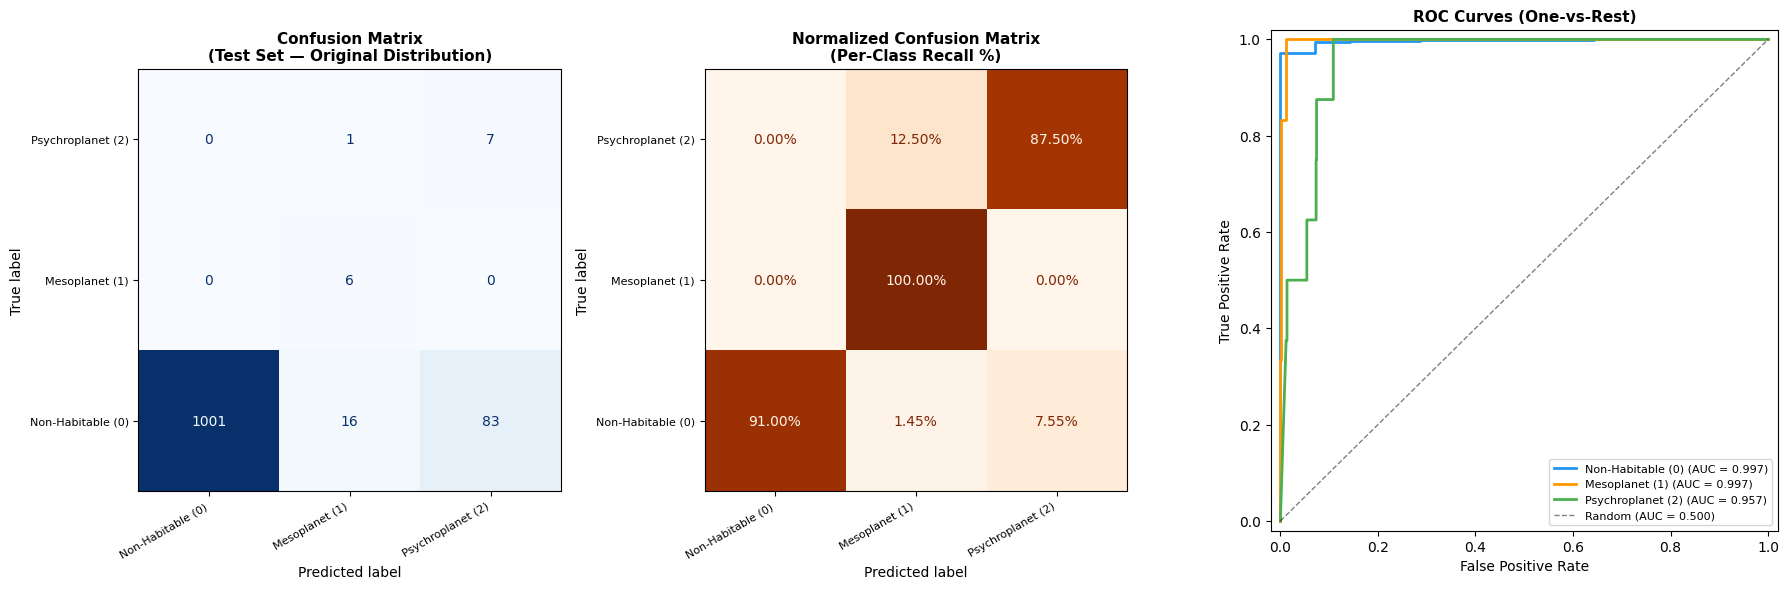


BASELINE SET — GNB provides the floor for all subsequent models.


In [ ]:
# ── Gaussian Naïve Bayes — Baseline Classifier ──
# GNB assumes features are independent and normally distributed per class.
# It has no class_weight parameter, so it relies entirely on the balanced
# training data from SMOTE. Expected to be the weakest model — sets the floor.

# ── 1. Train ──
gnb = GaussianNB()
gnb.fit(X_train_bal, y_train_bal)

# ── 2. Predict ──
y_pred = gnb.predict(X_test_scaled)
y_prob = gnb.predict_proba(X_test_scaled)

# ── GNB Diagnostic Plots: How the Model Works ──
# These visualizations show the internal mechanics of GNB,
# not just its final scores.

feature_names = FEATURES  # the 17 feature column names

# ============================================================================
# PLOT 1: Class-Conditional Gaussian Distributions (Top 6 Features)
# ============================================================================
# GNB literally IS these curves. For each feature, it fits a Gaussian
# N(μ, σ²) per class. At prediction time, it multiplies the likelihoods
# across all features. Where the curves overlap → confusion.

# Rank features by class separation (difference in means / pooled std)
separability = []
for j, feat in enumerate(feature_names):
    means = gnb.theta_[:, j]       # class means
    varis = gnb.var_[:, j]         # class variances
    spread = means.max() - means.min()
    pooled_std = np.sqrt(np.mean(varis))
    separability.append((spread / (pooled_std + 1e-12), feat, j))

separability.sort(reverse=True)
top_features = separability[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
colors = ["#2196F3", "#FF9800", "#4CAF50"]
class_labels = ["Non-Habitable (0)", "Mesoplanet (1)", "Psychroplanet (2)"]

for ax_idx, (sep_score, feat_name, feat_idx) in enumerate(top_features):
    ax = axes[ax_idx]

    # Plot the learned Gaussian for each class
    for c in range(3):
        mu = gnb.theta_[c, feat_idx]
        sigma = np.sqrt(gnb.var_[c, feat_idx])

        x_range = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        pdf = norm.pdf(x_range, mu, sigma)

        ax.plot(x_range, pdf, color=colors[c], lw=2.5, label=class_labels[c])
        ax.fill_between(x_range, pdf, alpha=0.15, color=colors[c])
        ax.axvline(mu, color=colors[c], ls="--", lw=1, alpha=0.6)

    ax.set_title(f"{feat_name}\n(separability = {sep_score:.2f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Scaled Feature Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("GNB Internals: Learned Class-Conditional Gaussians (Top 6 Features by Separability)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("gnb_class_conditionals.png", dpi=150, bbox_inches="tight")
plt.show()

print("↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.")
print("  Where curves overlap heavily → the model cannot distinguish classes on that feature alone.")
print("  High separability = curves are far apart = more useful feature.\n")

# ============================================================================
# PLOT 2: Predicted Posterior Probability Distributions by True Class
# ============================================================================
# For every test sample, GNB outputs P(class=0), P(class=1), P(class=2).
# This plot shows the distribution of those probabilities, grouped by
# what the sample ACTUALLY is. Reveals confidence and confusion patterns.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for true_cls in range(3):
    ax = axes[true_cls]
    mask = y_test == float(true_cls)
    probs = y_prob[mask]  # shape: (n_samples_in_class, 3)

    if probs.shape[0] == 0:
        ax.set_title(f"True: {class_labels[true_cls]}\n(no samples in test set)")
        continue

    parts = ax.violinplot(
        [probs[:, c] for c in range(3)],
        positions=[0, 1, 2],
        showmeans=True,
        showmedians=True,
    )

    # Color each violin by the predicted class it represents
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.4)

    # Style mean/median lines
    for key in ["cmeans", "cmedians"]:
        if key in parts:
            parts[key].set_color("black")

    # Overlay individual points (jittered) for small classes
    if probs.shape[0] <= 50:
        for c in range(3):
            jitter = np.random.normal(0, 0.04, size=probs.shape[0])
            ax.scatter(
                np.full(probs.shape[0], c) + jitter,
                probs[:, c],
                color=colors[c], s=25, alpha=0.7, edgecolors="black", linewidth=0.5, zorder=5
            )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["P(Non-Hab)", "P(Meso)", "P(Psychro)"], fontsize=9)
    ax.set_ylabel("Predicted Probability")
    ax.set_ylim([-0.05, 1.05])
    ax.set_title(f"True Class: {class_labels[true_cls]}\n(n = {mask.sum()})",
                 fontsize=11, fontweight="bold")
    ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)

fig.suptitle("GNB Posterior Probabilities: What does the model predict for each true class?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("gnb_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()

print("↑ For each true class, the violin shows the distribution of predicted probabilities.")
print("  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.")
print("  The spread in Non-Habitable's P(Psychro) violin explains the 83 false positives.")

In [ ]:
# Metrics
class_names = ["Non-Habitable (0)", "Mesoplanet (1)", "Psychroplanet (2)"]
classes = np.array([0.0, 1.0, 2.0])

f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("=" * 60)
print("GAUSSIAN NAÏVE BAYES — TEST SET RESULTS")
print("=" * 60)
print(f"\nF1 Score (macro):    {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

# ── 4. Cross-validation on balanced training set ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gnb, X_train_bal, y_train_bal, cv=cv, scoring="f1_macro")
print(f"5-Fold CV F1 (macro) on balanced train: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Per-fold: {[f'{s:.4f}' for s in cv_scores]}")

# ── 5. Visualizations ──
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2])

# ── Reorder: rows = [2, 1, 0] (top to bottom), cols = [0, 1, 2] (left to right) ──
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

row_order = [2, 1, 0]
class_names_rows = [class_names[i] for i in row_order]
class_names_cols = class_names

cm_reordered = cm[row_order, :]
cm_norm_reordered = cm_norm[row_order, :]

# ── Plot 1: Confusion Matrix ──
ax1 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reordered, display_labels=class_names_cols)
disp.plot(ax=ax1, cmap="Blues", values_format="d", colorbar=False)
ax1.set_yticklabels(class_names_rows, fontsize=8)
ax1.set_xticklabels(class_names_cols, rotation=30, ha="right", fontsize=8)
ax1.set_title("Confusion Matrix\n(Test Set — Original Distribution)", fontsize=11, fontweight="bold")

# ── Plot 2: Normalized Confusion Matrix (%) ──
ax2 = fig.add_subplot(gs[1])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm_reordered, display_labels=class_names_cols)
disp2.plot(ax=ax2, cmap="Oranges", values_format=".2%", colorbar=False)
ax2.set_yticklabels(class_names_rows, fontsize=8)
ax2.set_xticklabels(class_names_cols, rotation=30, ha="right", fontsize=8)
ax2.set_title("Normalized Confusion Matrix\n(Per-Class Recall %)", fontsize=11, fontweight="bold")

# ── Plot 3: One-vs-Rest ROC Curves ──
ax3 = fig.add_subplot(gs[2])
y_test_bin = label_binarize(y_test, classes=classes)
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, (cls, color, name) in enumerate(zip(classes, colors, class_names)):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax3.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.500)")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC Curves (One-vs-Rest)", fontsize=11, fontweight="bold")
ax3.legend(loc="lower right", fontsize=8)
ax3.set_xlim([-0.02, 1.02])
ax3.set_ylim([-0.02, 1.02])

plt.tight_layout()
# plt.savefig("gnb_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*60}")
print("BASELINE SET — GNB provides the floor for all subsequent models.")
print(f"{'='*60}")

### Interpretation:
The GNB baseline shows strong signal but poor reliability.

It performs very well on the dominant class (Non-Habitable), with near-perfect precision and high recall, which drives the overall accuracy (91%) and weighted F1 (0.94). It also achieves high recall across all classes, meaning it rarely misses habitable planets—an important property.

However, precision for the rare classes is extremely low. The model heavily over-predicts Mesoplanet and Psychroplanet, producing many false positives. Because those classes have very few true samples (6 and 8), even a small number of mistakes overwhelms the correct predictions, leading to a low macro F1 (0.50).

The gap between cross-validation (0.86) and test performance (0.50) shows the core issue: the model learns well on balanced (SMOTE) data but fails on the real, imbalanced distribution. This is compounded by Naïve Bayes assumptions—feature independence and Gaussian distributions—which don’t hold for correlated, skewed features.

Overall, the model confirms that the features contain strong predictive signal (high AUC), but it cannot produce reliable class decisions. It sets a useful baseline: future models need to improve macro F1 and especially precision on the minority classes.


## Linear Discriminant Analysis (LDA)

In [ ]:
# Linear Discriminant Analysis (LDA)